In [1]:
from pycocotools.coco import COCO


coco = COCO("data/coco_tank_photos/result.json")
coco2 = COCO("data/coco_tank_photos2/result.json")
img_ids = coco.getImgIds()

num_samples = len(coco.imgs) + len(coco2.imgs) - 47


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [2]:
import numpy as np
import tensorflow as tf
from keras.utils import img_to_array, load_img
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def load_image(data : COCO, img_id, target_size=(400,400), num_od_ds=""):
    img_dir = f"data/coco_tank_photos{num_od_ds}/" + data.loadImgs(img_id)[0]["file_name"].replace("/", "/")
    img = img_to_array(load_img(path=img_dir, target_size=target_size)) / 255.

    orig_sizes = (data.loadImgs(img_id)[0]["width"], data.loadImgs(img_id)[0]["height"])

    boxes = []
    for i in range(len(data.loadAnns(data.getAnnIds(img_id)))):
        x, y, w, h = data.loadAnns(data.getAnnIds(img_id))[i]["bbox"]
        x1 = x / orig_sizes[0]
        w1 = w / orig_sizes[0]
        y1 = y / orig_sizes[1]
        h1 = h / orig_sizes[1]

        importance = 0

        if [x1, y1, w1, h1] != [0, 0, 0, 0]:
            importance = 1

        boxes.append([x1, y1, w1, h1, importance])

    return img, np.array(boxes, np.float32)

2025-12-03 22:20:35.236110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764789635.255087   32441 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764789635.261079   32441 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764789635.276313   32441 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764789635.276337   32441 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764789635.276339   32441 computation_placer.cc:177] computation placer alr

In [3]:
images_ds = np.zeros((num_samples, 400, 400, 3), dtype="float32")
labels_ds = np.zeros((num_samples, 5, 5), dtype="float32")
for i in range(num_samples):
    try:
        image, boxes = load_image(coco, i)
    except:
        image, boxes = load_image(coco2, i - len(coco.imgs), num_od_ds="2")
    if len(boxes) > 5:
        continue
    for j in range(len(boxes)):
        labels_ds[i][j] = boxes[j]
    images_ds[i] = image

In [4]:
def show_image(image, boxes=np.zeros((15, 5), dtype=np.float32), original_size=(400, 400), ignore_objectnesses=False, alpha=0.5, output=None, color="red"):
    fig, ax = plt.subplots()
    ax.imshow(image)


    for i in range(len(boxes)):
        if ignore_objectnesses or boxes[i][4] >= alpha:
            rect = patches.Rectangle((boxes[i][0] * original_size[0], boxes[i][1]* original_size[1]), boxes[i][2]* original_size[0], boxes[i][3]* original_size[1], fill=False, color=color)
            ax.add_patch(rect)
            continue
    
    if output:
        plt.savefig(output, dpi=300)
        plt.close()
    else:
        plt.show()

In [5]:
from keras import layers
import keras

@keras.saving.register_keras_serializable()
def iou_loss(y_true, y_pred):
    y_pred_conf = y_pred[..., 4:]
    y_true_conf = y_true[..., 4:]
    y_true = y_true[..., :4]
    y_pred = y_pred[..., :4]

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred_conf = tf.cast(y_pred_conf, tf.float32)
    y_true_conf = tf.cast(y_true_conf, tf.float32)

    y_pred = tf.where(
        y_pred_conf < 0.5,
        0.,
        y_pred
    )

    w_area = tf.maximum(0., tf.minimum(y_true[..., 0] + y_true[..., 2], y_pred[..., 0] + y_pred[..., 2]) - tf.maximum(y_true[..., 0], y_pred[..., 0]))
    h_area = tf.maximum(0., tf.minimum(y_true[..., 1] + y_true[..., 3], y_pred[..., 1] + y_pred[..., 3]) - tf.maximum(y_true[..., 1], y_pred[..., 1]))
    s_area = w_area * h_area

    s_true = y_true[..., 2] * y_true[..., 3]
    s_pred = y_pred[..., 2] * y_pred[..., 3]

    union = s_true + s_pred - s_area
    iou = (s_area + 1e-7) / (union + 1e-7)

    x1c = tf.minimum(y_true[..., 0], y_pred[..., 0])
    y1c = tf.minimum(y_true[..., 1], y_pred[..., 1])
    x2c = tf.maximum(y_true[..., 0] + y_true[..., 2], y_pred[..., 0] + y_pred[..., 2])
    y2c = tf.maximum(y_true[..., 1] + y_true[..., 3], y_pred[..., 1] + y_pred[..., 3])

    #c = (x2c - x1c) * (y2c - y1c)

    #giou = iou - (c - union) / (c + 1e-7)

    conf = keras.losses.binary_crossentropy(y_true_conf, y_pred_conf)

    b_pred_x = y_pred[..., 0] + y_pred[..., 2] / 2.
    b_pred_y = y_pred[..., 1] + y_pred[..., 3] / 2.

    b_true_x = y_true[..., 0] + y_true[..., 2] / 2.
    b_true_y = y_true[..., 1] + y_true[..., 3] / 2.

    p2 = tf.square(b_pred_x - b_true_x) + tf.square(b_pred_y - b_true_y)

    c2 = tf.square(x2c - x1c) + tf.square(y2c - y1c)

    v = 4 / tf.square(3.141592) * tf.square(tf.atan(tf.math.divide_no_nan(y_true[..., 2], y_true[..., 3])) - tf.atan(tf.math.divide_no_nan(y_pred[..., 2], y_pred[..., 3])))

    a = v / ((1 - iou) + v + 1e-7)

    ciou = tf.math.divide_no_nan(p2, c2) + a*v

    return tf.reduce_mean(1.0 - iou + ciou) + tf.reduce_mean(0.25 * conf)

In [6]:
@keras.saving.register_keras_serializable()
def iou_metric(y_true, y_pred):
    y_pred_conf = y_pred[..., 4:]
    y_true = y_true[..., :4]
    y_pred = y_pred[..., :4]

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred_conf = tf.cast(y_pred_conf, tf.float32)

    y_pred = tf.where(
        y_pred_conf < 0.5,
        0.,
        y_pred
    )

    w_area = tf.maximum(0., tf.minimum(y_true[..., 0] + y_true[..., 2], y_pred[..., 0] + y_pred[..., 2]) - tf.maximum(y_true[..., 0], y_pred[..., 0]))
    h_area = tf.maximum(0., tf.minimum(y_true[..., 1] + y_true[..., 3], y_pred[..., 1] + y_pred[..., 3]) - tf.maximum(y_true[..., 1], y_pred[..., 1]))
    s_area = w_area * h_area

    s_true = y_true[..., 2] * y_true[..., 3]
    s_pred = y_pred[..., 2] * y_pred[..., 3]

    union = s_true + s_pred - s_area
    iou = (s_area + 1e-7) / (union + 1e-7)


    return tf.reduce_mean(iou)

@keras.saving.register_keras_serializable()
def giou_metric(y_true, y_pred):
    y_pred_conf = y_pred[..., 4:]
    y_true = y_true[..., :4]
    y_pred = y_pred[..., :4]

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred_conf = tf.cast(y_pred_conf, tf.float32)

    y_pred = tf.where(
        y_pred_conf < 0.5,
        0.,
        y_pred
    )

    w_area = tf.maximum(0., tf.minimum(y_true[..., 0] + y_true[..., 2], y_pred[..., 0] + y_pred[..., 2]) - tf.maximum(y_true[..., 0], y_pred[..., 0]))
    h_area = tf.maximum(0., tf.minimum(y_true[..., 1] + y_true[..., 3], y_pred[..., 1] + y_pred[..., 3]) - tf.maximum(y_true[..., 1], y_pred[..., 1]))
    s_area = w_area * h_area

    s_true = y_true[..., 2] * y_true[..., 3]
    s_pred = y_pred[..., 2] * y_pred[..., 3]

    union = s_true + s_pred - s_area
    iou = (s_area + 1e-7) / (union + 1e-7)

    x1c = tf.minimum(y_true[..., 0], y_pred[..., 0])
    y1c = tf.minimum(y_true[..., 1], y_pred[..., 1])
    x2c = tf.maximum(y_true[..., 0] + y_true[..., 2], y_pred[..., 0] + y_pred[..., 2])
    y2c = tf.maximum(y_true[..., 1] + y_true[..., 3], y_pred[..., 1] + y_pred[..., 3])

    c = (x2c - x1c) * (y2c - y1c)

    giou = iou - (c - union) / (c + 1e-7)

    return tf.reduce_mean(giou)

@keras.saving.register_keras_serializable()
def mean_binary_crossentropy_metric(y_true, y_pred):
    y_true_obj = y_true[..., 4]
    y_pred_obj = y_pred[..., 4]

    y_true_obj = tf.cast(y_true_obj, tf.float32) + 1e-6
    y_pred_obj = tf.cast(y_pred_obj, tf.float32) + 1e-6

    conf = keras.losses.binary_crossentropy(y_true_obj, y_pred_obj)
    conf = tf.reduce_mean(conf)

    return conf

@keras.saving.register_keras_serializable()
def ciou_metric(y_true, y_pred):
    y_pred_conf = y_pred[..., 4:]
    y_true_conf = y_true[..., 4:]
    y_true = y_true[..., :4]
    y_pred = y_pred[..., :4]

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred_conf = tf.cast(y_pred_conf, tf.float32)
    y_true_conf = tf.cast(y_true_conf, tf.float32)

    y_pred = tf.where(
        y_pred_conf < 0.5,
        0.,
        y_pred
    )

    w_area = tf.maximum(0., tf.minimum(y_true[..., 0] + y_true[..., 2], y_pred[..., 0] + y_pred[..., 2]) - tf.maximum(y_true[..., 0], y_pred[..., 0]))
    h_area = tf.maximum(0., tf.minimum(y_true[..., 1] + y_true[..., 3], y_pred[..., 1] + y_pred[..., 3]) - tf.maximum(y_true[..., 1], y_pred[..., 1]))
    s_area = w_area * h_area

    s_true = y_true[..., 2] * y_true[..., 3]
    s_pred = y_pred[..., 2] * y_pred[..., 3]

    union = s_true + s_pred - s_area
    iou = (s_area + 1e-7) / (union + 1e-7)

    x1c = tf.minimum(y_true[..., 0], y_pred[..., 0])
    y1c = tf.minimum(y_true[..., 1], y_pred[..., 1])
    x2c = tf.maximum(y_true[..., 0] + y_true[..., 2], y_pred[..., 0] + y_pred[..., 2])
    y2c = tf.maximum(y_true[..., 1] + y_true[..., 3], y_pred[..., 1] + y_pred[..., 3])

    b_pred_x = y_pred[..., 0] + y_pred[..., 2] / 2.
    b_pred_y = y_pred[..., 1] + y_pred[..., 3] / 2.

    b_true_x = y_true[..., 0] + y_true[..., 2] / 2.
    b_true_y = y_true[..., 1] + y_true[..., 3] / 2.

    p2 = tf.square(b_pred_x - b_true_x) + tf.square(b_pred_y - b_true_y)

    c2 = tf.square(x2c - x1c) + tf.square(y2c - y1c)

    v = 4 / tf.square(3.141592) * tf.square(tf.atan(tf.math.divide_no_nan(y_true[..., 2], y_true[..., 3])) - tf.atan(tf.math.divide_no_nan(y_pred[..., 2], y_pred[..., 3])))

    a = v / ((1 - iou) + v + 1e-7)

    ciou = tf.math.divide_no_nan(p2, c2) + a*v

    return tf.reduce_mean(iou - ciou)

In [7]:
np.random.default_rng(888).shuffle(images_ds)

np.random.default_rng(888).shuffle(labels_ds)

train_images = images_ds[50:]
train_labels = labels_ds[50:]

val_images = images_ds[10:50]
val_labels = labels_ds[10:50]

test_images = images_ds[:10]
test_labels = labels_ds[:10]

In [8]:
model_name = "f435825ee3d44b03b985785866911efe"

keras.mixed_precision.set_global_policy('mixed_float16')

model = keras.saving.load_model(f"mlartifacts/0/{model_name}/artifacts/model.keras")

I0000 00:00:1764789646.775469   32441 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9138 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:24:00.0, compute capability: 8.6
/home/arseniy/anaconda3/envs/tf/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 65 variables whereas the saved optimizer has 124 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/arseniy/anaconda3/envs/tf/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 61 variables whereas the saved optimizer has 120 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [12]:
k = 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


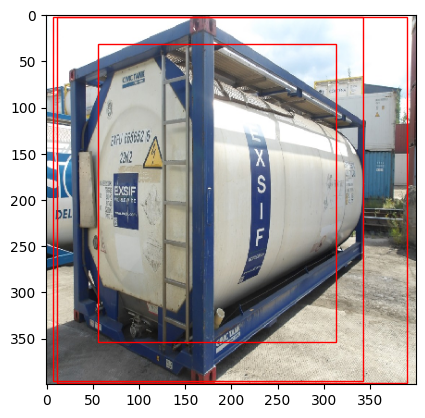

array([[0.14, 0.08, 0.64, 0.81, 0.98],
       [0.03, 0.  , 0.95, 0.99, 0.92],
       [0.02, 0.01, 0.84, 0.98, 0.72],
       [0.11, 0.03, 0.72, 0.95, 0.29],
       [0.24, 0.24, 0.83, 0.92, 0.1 ]], dtype=float16)

In [ ]:
test_photo = np.ndarray(shape=(1, 400, 400, 3), dtype="float32")
test_photo[0] = images_ds[k]
test_boxes = model.predict(test_photo)
show_image(test_photo[0], test_boxes[0], alpha=0.5)
k+=1
test_boxes[0].round(2)

In [11]:
model.evaluate(images_ds, labels_ds)

2025-12-03 22:20:56.919275: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1098240000 exceeds 10% of free system memory.
2025-12-03 22:20:57.696815: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1098240000 exceeds 10% of free system memory.
2025-12-03 22:21:00.677329: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_648', 256 bytes spill stores, 256 bytes spill loads

2025-12-03 22:21:00.719674: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_655', 448 bytes spill stores, 448 bytes spill loads

2025-12-03 22:21:06.559561: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investig

17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - ciou_metric: 0.6494 - giou_metric: 0.6505 - iou_metric: 0.7165 - loss: 0.3996 - mean_binary_crossentropy_metric: 0.1959

2025-12-03 22:21:42.274223: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_648', 240 bytes spill stores, 240 bytes spill loads

2025-12-03 22:21:42.330464: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_648', 376 bytes spill stores, 440 bytes spill loads

2025-12-03 22:21:42.444683: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_655', 480 bytes spill stores, 480 bytes spill loads

2025-12-03 22:21:42.488839: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_648_0', 4 bytes spill stores, 4 bytes spill loads

2025-12-03 22:21:47.937016: E external

18/18 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - ciou_metric: 0.6492 - giou_metric: 0.6517 - iou_metric: 0.7143 - loss: 0.3942 - mean_binary_crossentropy_metric: 0.1759


[0.39421945810317993,
 0.17589938640594482,
 0.7142807245254517,
 0.6516970992088318,
 0.6491977572441101]